In [11]:
from astropy.io import ascii

import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack, hstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18


import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches

# from consolidate_photometry import get_fastspec_fit_catalog_V2

from fastspec_funcs import get_fastspecfit_path, measure_photo_batch

%load_ext autoreload
%autoreload 2

MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from desispec.interpolation import resample_flux
from desi_lowz_funcs import g_kcorr, r_kcorr


In [13]:
from fastspecfit.io import read_fastspecfit
from fastspecfit.singlecopy import sc_data
from fastspecfit.continuum import ContinuumTools
from fastspecfit.photometry import Photometry
from fastspecfit.util import FLUXNORM

In [14]:
import os
import numpy as np
import speclite.filters
from tqdm.notebook import trange
from astropy.io import fits
from desispec.interpolation import resample_flux
from desi_lowz_funcs import g_kcorr, r_kcorr
from fastspecfit.io import read_fastspecfit
from fastspecfit.singlecopy import sc_data
from fastspecfit.continuum import ContinuumTools
from fastspecfit.photometry import Photometry
from fastspecfit.util import FLUXNORM

# -------------------------------------------------------------------------
# One-time setup: load the SPS templates, photometry config, IGM, cosmology.
# Heavy; do it once outside the loop.
# -------------------------------------------------------------------------
sc_data.initialize(fastphot=False)
templates = sc_data.templates
phot      = sc_data.photometry
cosmo     = sc_data.cosmology
igm       = sc_data.igm

# -------------------------------------------------------------------------
# Switch to SDSS filters everywhere (your original code used DECam by mistake)
# -------------------------------------------------------------------------
SDSS_G = speclite.filters.load_filter('sdss2010noatm-g')
SDSS_R = speclite.filters.load_filter('sdss2010noatm-r')

SDSS_GR_FILTERS = speclite.filters.load_filters("sdss2010noatm-g", "sdss2010noatm-r")


In [22]:
bgsb_int_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")
bgsf_int_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_faint_filter_zsucc_zrr03_allfracflux_INT_V2_NEBCORR.fits")
elg_int_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_elg_filter_zsucc_zrr05_allfracflux_INT_V2_NEBCORR.fits")

print(len(bgsb_int_cat))
print(len(bgsf_int_cat))
print(len(elg_int_cat))

bgs_cat = vstack([bgsb_int_cat, bgsf_int_cat])


195376
66912
187920


In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from speclite import filters as specfilters

@ticker.FuncFormatter
def _major_formatter(x, pos):
    if 0.01 <= x < 0.1:   return f'{x:.2f}'
    elif 0.1 <= x < 1:    return f'{x:.1f}'
    else:                 return f'{x:.0f}'


def diagnostic_sed_plot(zred, tgid, photsys,
                        wave_obs, model_spec_obs,
                        sedwave_j, sedmodel_j,
                        nanomaggies_j, ivar_nanomaggies_j,
                        filters_in_j, lambda_in_j):
    """Compare MODELS-HDU continuum vs FastSpecFit COEFF-rebuilt SED."""

    # MODELS is in 1e-17 erg/s/cm^2/A, same as FLUXNORM convention.
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 3.5))

    wave_mask_1 = (wave_obs > 5000) & (wave_obs < 5500)
    wave_mask_2 = (sedwave_j > 5000) & (sedwave_j < 5500)
    
    scale_fac = np.median(model_spec_obs[wave_mask_1])/np.median(sedmodel_j[wave_mask_2])
    

    ax.plot(wave_obs, model_spec_obs,
            color='C3', lw=1.0, alpha=0.85,
            label='MODELS-HDU continuum (your input)')

    # wave_obs_f = np.arange(3000, 11000, np.diff(wave_obs)[0])
    # model_obs_f = resample_flux(wave_obs_f, wave_obs, model_spec_obs, extrapolate=True)

    ax.plot(sedwave_j, sedmodel_j * scale_fac ,
    color='C0', lw=1.0, alpha=0.85,
    label='FastSpecFit COEFF-rebuilt SED')

    
    ax.plot(wave_obs_f, model_obs_f,
            color='C3', lw=1.0, alpha=0.4)

    # ax.scatter(obs_lambda / 1e4, obs_abmag,
    #            marker='o', s=80, color='orange', zorder=3, alpha=0.85,
    #            label='Observed photometry')
    # ax.scatter(lambda_in_j / 1e4, model_abmag_fsf,
    #            marker='s', s=110, color='C0', facecolor='none', zorder=4,
    #            label='Synth photometry (COEFF rebuild)')
    # ax.scatter(lambda_in_j / 1e4, model_abmag_modelshdu,
    #            marker='^', s=110, color='C3', facecolor='none', zorder=4,
    #            label='Synth photometry (MODELS-HDU)')

    # Print diff
    # diff = model_abmag_fsf - model_abmag_modelshdu
    # print(f"  Per-band [FSF rebuild] - [MODELS HDU] (mag):")
    # for b, d in zip(phot.bands, diff):
    #     print(f"    {b:>4}: {d:+.4f}")

    ax.legend(loc='upper right', fontsize=10, frameon=False)
    # ax.set_ylim(25, 14)
    ax.set_xlim(3000, 11000)
    # ax.set_ylim([0,1])
    ax.set_xlabel(r'Observed-frame wavelength')
    ax.set_title(f'TARGETID = {tgid}, photsys = {photsys}, z = {zred:.4f}')
    fig.tight_layout()
    plt.show()

In [26]:
# -------------------------------------------------------------------------
# Custom K-correction helper (copied verbatim from the v3 tutorial)
# -------------------------------------------------------------------------
from speclite import filters as specfilters

def custom_kcorr_and_absmag(redshift, dmod, sedwave, sedflux,
                            nanomaggies, ivar_nanomaggies,
                            filters_in, lambda_in, bands_to_fit,
                            absmag_filters, band_shifts, snrmin=2.):
    filters_out = specfilters.FilterSequence([
        f.create_shifted(band_shift=bs)
        for f, bs in zip(absmag_filters, band_shifts)
    ])
    synth_maggies_rest = Photometry.get_ab_maggies_unchecked(
        filters_out, sedflux * (1. + redshift) / FLUXNORM,
        sedwave / (1. + redshift),
    )
    synth_absmag = -2.5 * np.log10(synth_maggies_rest) - dmod

    synth_maggies_obs = Photometry.get_ab_maggies_unchecked(
        filters_in, sedflux / FLUXNORM, sedwave,
    )

    maggies     = nanomaggies * 1e-9
    ivarmaggies = (np.asarray(ivar_nanomaggies) / 1e-9**2) * np.asarray(bands_to_fit)
    lambda_out  = filters_out.effective_wavelengths.value

    nout = len(absmag_filters)
    oband = np.empty(nout, dtype=np.int16)
    bad_snr = (maggies * np.sqrt(ivarmaggies) < snrmin)
    for j in range(nout):
        d = np.abs(lambda_in / (1. + redshift) - lambda_out[j])
        oband[j] = np.argmin(d + bad_snr * 1e10)

    kcorr = 2.5 * np.log10(synth_maggies_rest / synth_maggies_obs[oband])

    absmag = synth_absmag.copy()
    ivarabsmag = np.zeros_like(absmag)
    good = (maggies[oband] * np.sqrt(ivarmaggies[oband]) > snrmin)
    if np.any(good):
        C = (0.4 * np.log(10.))**2
        absmag[good] = -2.5 * np.log10(maggies[oband[good]]) - dmod - kcorr[good]
        ivarabsmag[good] = (maggies[oband[good]]**2
                            * ivarmaggies[oband[good]] * C)

    return kcorr, absmag, ivarabsmag, synth_absmag


In [27]:
def custom_kcorr_minimal(redshift, sedwave, sedflux,
                         absmag_filters, band_shifts=None):
    """
    Same-band K-correction(s) computed entirely from a model SED.

    K_X(z) = m_X(observed) - M_X(rest)
           = 2.5 * log10( synth_maggies_rest / synth_maggies_obs )

    where both maggies are synthesized through filter X, on the model SED.

    Parameters
    ----------
    redshift : float
    sedwave  : (N,) array, observed-frame wavelength of the SED [Angstrom]
    sedflux  : (N,) array, observed-frame flux density of the SED
               in the same units fastspecfit uses (1e-17 erg/s/cm^2/A * FLUXNORM)
    absmag_filters : speclite FilterSequence (e.g. SDSS u,g,r,i,z)
    band_shifts    : iterable of band-shifts, one per filter. Defaults to all zeros
                     (i.e. rest-frame at z=0).

    Returns
    -------
    kcorr : (Nfilt,) array of K-corrections, in magnitudes.
    """
    if band_shifts is None:
        band_shifts = np.zeros(len(absmag_filters))

    filters_rest = specfilters.FilterSequence([
        f.create_shifted(band_shift=bs)
        for f, bs in zip(absmag_filters, band_shifts)
    ])

    # Rest frame: de-redshift the SED (F_lambda_rest = F_lambda_obs * (1+z),
    # lambda_rest = lambda_obs / (1+z)) and integrate through the (possibly
    # band-shifted) rest-frame filter.
    synth_maggies_rest = Photometry.get_ab_maggies_unchecked(
        filters_rest,
        sedflux * (1. + redshift) / FLUXNORM,
        sedwave / (1. + redshift),
    )

    # Observed frame: integrate the same SED, in observed frame, through the
    # un-shifted absmag filter (this is the "same filter" on the obs side).
    synth_maggies_obs = Photometry.get_ab_maggies_unchecked(
        absmag_filters,
        sedflux / FLUXNORM,
        sedwave,
    )

    kcorr = 2.5 * np.log10(synth_maggies_rest / synth_maggies_obs)
    return kcorr

In [28]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def smooth_and_extrapolate(x, y, new_xmin, new_xmax, sigma=1.0):
    # Smooth y with gaussian kernel
    y_smooth = gaussian_filter1d(y, sigma=sigma)
    
    # Fit linear slope at left edge using first few points
    n_edge = max(3, int(len(x) * 0.05))  # use 5% of points, min 3
    
    left_slope = np.polyfit(x[:n_edge], y_smooth[:n_edge], 1)[0]
    right_slope = np.polyfit(x[-n_edge:], y_smooth[-n_edge:], 1)[0]
    
    dx = x[1] - x[0]  # assumes uniform spacing
    
    # Build left extension
    if new_xmin < x[0]:
        x_left = np.arange(x[0] - dx, new_xmin - dx, -dx)[::-1]
        y_left = y_smooth[0] + left_slope * (x_left - x[0])
    else:
        x_left, y_left = np.array([]), np.array([])
    
    # Build right extension
    if new_xmax > x[-1]:
        x_right = np.arange(x[-1] + dx, new_xmax + dx, dx)
        y_right = y_smooth[-1] + right_slope * (x_right - x[-1])
    else:
        x_right, y_right = np.array([]), np.array([])
    
    x_out = np.concatenate([x_left, x, x_right])
    y_out = np.concatenate([y_left, y_smooth, y_right])
    
    return x_out, y_out

In [29]:
from scipy.ndimage import gaussian_filter1d
import numpy as np



HPX=0
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/0/fastspec-main-bright-0.fits.gz


  0%|          | 0/28 [00:00<?, ?it/s]

39627803590660098


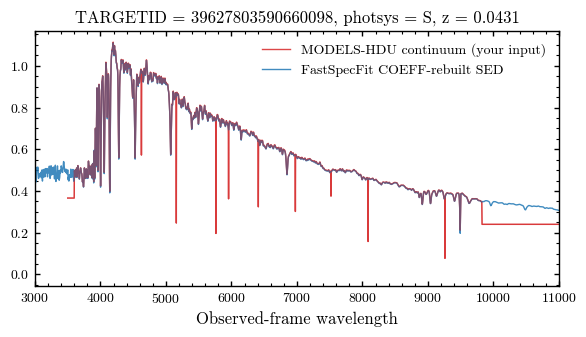

HPX=1
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/1/fastspec-main-bright-1.fits.gz


  0%|          | 0/16 [00:00<?, ?it/s]

39627815687028846


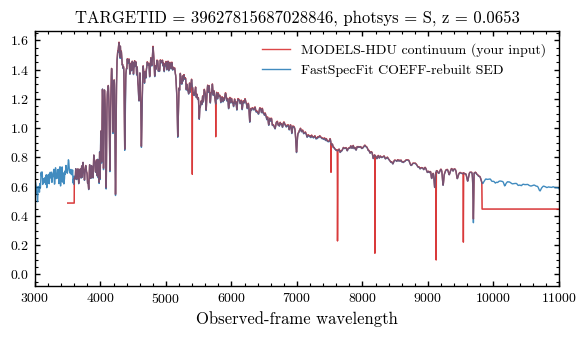

HPX=2
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/2/fastspec-main-bright-2.fits.gz


  0%|          | 0/19 [00:00<?, ?it/s]

39627809626262667


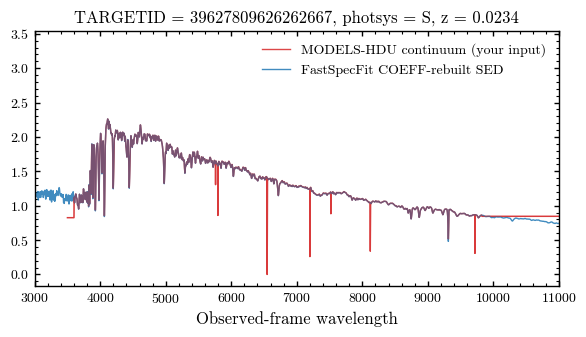

HPX=3
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/3/fastspec-main-bright-3.fits.gz


  0%|          | 0/24 [00:00<?, ?it/s]

39627821718444843


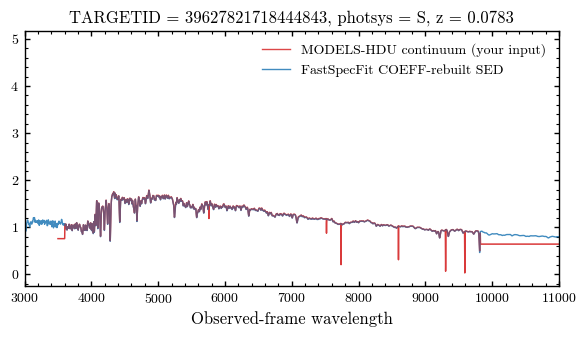

HPX=4
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/4/fastspec-main-bright-4.fits.gz


  0%|          | 0/14 [00:00<?, ?it/s]

39627815703808847


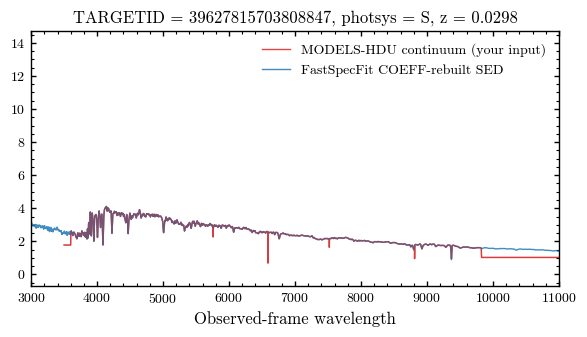

HPX=5
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/5/fastspec-main-bright-5.fits.gz


  0%|          | 0/13 [00:00<?, ?it/s]

39627839883970669


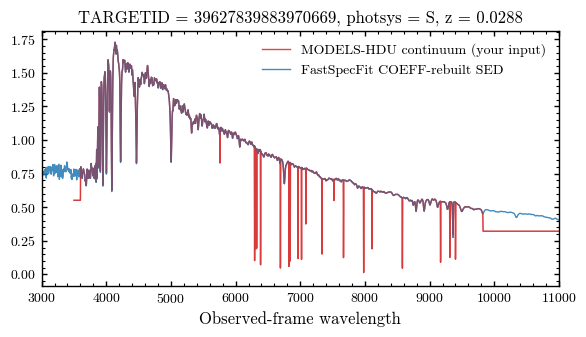

HPX=6
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/6/fastspec-main-bright-6.fits.gz


  0%|          | 0/7 [00:00<?, ?it/s]

39627833810618972


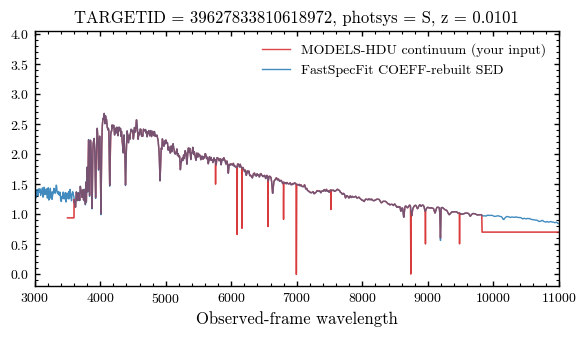

HPX=7
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/7/fastspec-main-bright-7.fits.gz


  0%|          | 0/2 [00:00<?, ?it/s]

39627864026387108


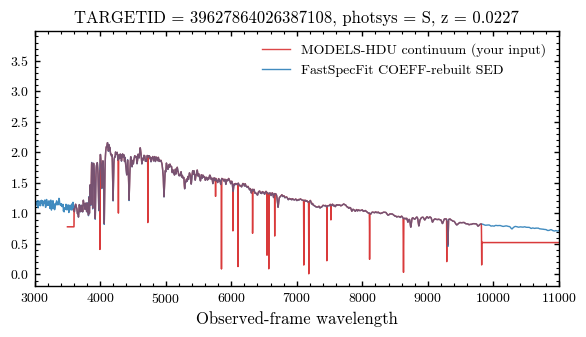

HPX=8
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/8/fastspec-main-bright-8.fits.gz


  0%|          | 0/16 [00:00<?, ?it/s]

39627839816866552


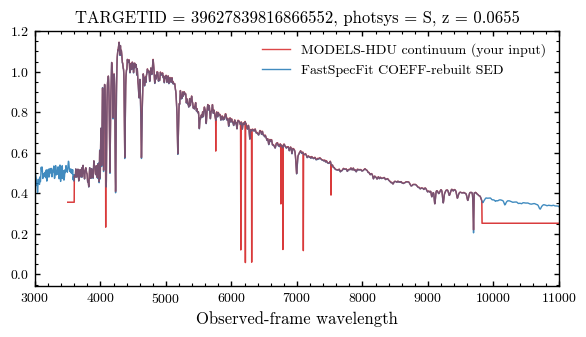

HPX=9
/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/9/fastspec-main-bright-9.fits.gz


  0%|          | 0/20 [00:00<?, ?it/s]

39627851909043617


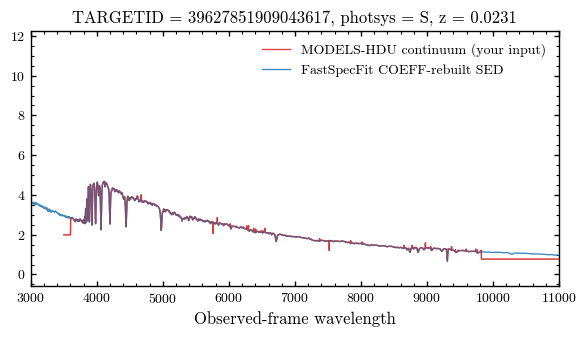

In [32]:

# -------------------------------------------------------------------------
# Main loop
# -------------------------------------------------------------------------
meas_kcorr_g = []
meas_kcorr_r = []
old_kcorr_g  = []
old_kcorr_r  = []
fsf_kcorr_g  = []     # NEW: FastSpecFit-based via custom_kcorr_and_absmag
fsf_kcorr_r  = []     # NEW: FastSpecFit-based via stored KCORR00_SDSS_R
all_zreds    = []
c10_kcorr_g  = []
c10_kcorr_r  = []
all_tgids = []

fastspec_version = "v3.0"

for hpx in np.unique(bgsb_int_cat["HEALPIX"].data)[:10]:
    plot_index = 0
    print(f"HPX={hpx}")

    elg_cat = bgsb_int_cat[
        (bgsb_int_cat["PROGRAM"] == "bright")
        & (bgsb_int_cat["SURVEY"] == "main")
        & (bgsb_int_cat["HEALPIX"] == hpx)
    ]
    elg_tgids = set(elg_cat["TARGETID"].data.tolist())

    fspec_path = get_fastspecfit_path("main", "bright", hpx, base_dir=f"/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/{fastspec_version}/healpix" )
    print(fspec_path)

    # --- Read everything we need from the file ---
    # MODELS for the legacy "old" continuum spectrum,
    # FASTSPEC for redshifts and TARGETIDs (matches MODELS rows),
    # METADATA for nanomaggies / MW_TRANSMISSION,
    # SPECPHOT for COEFF / TAUV / VDISP / KCORR00_SDSS_R.
    iron_vac = fits.open(fspec_path, memmap=True)

    header     = iron_vac["MODELS"].header
    wave_obs   = (header["CRVAL1"]
                  + (np.arange(header["NAXIS1"]) - header["CRPIX1"]) * header["CDELT1"])
    model_data = iron_vac["MODELS"].data

    fastspec_data = iron_vac["FASTSPEC"].data
    metadata      = iron_vac["METADATA"].data
    if fastspec_version == "v3.0":
        specphot      = iron_vac["SPECPHOT"].data

    iron_vac.close()  # done reading

    # Sanity: row order must match across HDUs in fastspec files.
    assert np.array_equal(fastspec_data["TARGETID"], metadata["TARGETID"]), \
    "Row order mismatch between FASTSPEC and METADATA!"

    if fastspec_version == "v3.0":
        assert np.array_equal(fastspec_data["TARGETID"], specphot["TARGETID"]), \
            "Row order mismatch between FASTSPEC and SPECPHOT!"

    # --- Vectorized pre-filter (Q4) ---
    fs_tgids = fastspec_data["TARGETID"]
    fs_zred  = metadata["Z"]
    in_elg   = np.isin(fs_tgids, list(elg_tgids))
    mask     = (fs_zred < 0.45) & in_elg
    valid_indices = np.where(mask)[0]

    for i in trange(len(valid_indices)):
        idx  = valid_indices[i]
        tgid = fs_tgids[idx]
        zred = float(fs_zred[idx])
        all_zreds.append(zred)

        all_tgids.append(tgid)

        # ============================================================
        # Method 3 (NEW): FastSpecFit machinery
        # ============================================================
        photsys = str(metadata["PHOTSYS"][idx])
        
        if fastspec_version == "v3.0":
            coeff   = np.array(specphot["COEFF"][idx])
            tauv    = float(specphot["TAUV"][idx])
            vdisp    = float(specphot["VDISP"][idx])

        if fastspec_version == "v2.1":
            coeff   = np.array(fastspec_data["COEFF"][idx])
            tauv    = float(fastspec_data["TAUV"][idx])
            vdisp    = float(fastspec_data["VDISP"][idx])
        
        dlum = cosmo.luminosity_distance(zred)
        dmod = cosmo.distance_modulus(zred)
        
        data_j = {
            "uniqueid"   : int(tgid),
            "redshift"   : zred,
            "dluminosity": dlum,
            "dmodulus"   : dmod,
            "photsys"    : photsys,
            "tuniv"      : 100.,
        }
        CTools_j = ContinuumTools(data_j, templates, phot, igm, fastphot=True)
        # sedmodel_j = CTools_j.build_stellar_continuum(
        #     templates.flux_nomvdisp, coeff,
        #     tauv=tauv, vdisp=None,
        # )

        sedmodel_j = CTools_j.build_stellar_continuum(
            templates.flux_nolines_nomvdisp, coeff,
            tauv=tauv, vdisp=None,
            dust_emission=False,
        )
        
        sedwave_j = CTools_j.ztemplatewave

        nanomaggies_j      = np.zeros(len(phot.bands))
        ivar_nanomaggies_j = np.zeros(len(phot.bands))
        for ib, band in enumerate(phot.bands):
            tr = float(metadata[f"MW_TRANSMISSION_{band.upper()}"][idx])
            nanomaggies_j[ib]      = float(metadata[f"FLUX_{band.upper()}"][idx]) / tr
            ivar_nanomaggies_j[ib] = float(metadata[f"FLUX_IVAR_{band.upper()}"][idx]) * tr**2
        
        filters_in_j = phot.filters[photsys]
        lambda_in_j  = filters_in_j.effective_wavelengths.value

        # # Both g and r through the custom helper at band_shift = 0
        # kcorr_gr_fsf, _, _, _ = custom_kcorr_and_absmag(
        #     zred, dmod, sedwave_j, sedmodel_j,
        #     nanomaggies_j, ivar_nanomaggies_j,
        #     filters_in=filters_in_j, lambda_in=lambda_in_j,
        #     bands_to_fit=phot.bands_to_fit,
        #     absmag_filters=SDSS_GR_FILTERS, band_shifts=[0.0, 0.0],
        # )
        # kcorr_g_fsf = float(kcorr_gr_fsf[0])
        # kcorr_r_fsf = float(kcorr_gr_fsf[1])

        kcorr_gr = custom_kcorr_minimal(
            zred,
            sedwave_j,            # CTools_j.ztemplatewave
            sedmodel_j,           # from build_stellar_continuum (lines or no-lines, your choice)
            absmag_filters=SDSS_GR_FILTERS,
            band_shifts=[0.0, 0.0],
        )
        kcorr_g_fsf, kcorr_r_fsf = float(kcorr_gr[0]), float(kcorr_gr[1])

        # ============================================================
        # Method 1 (your existing code): redshifted-filter Method A
        # ============================================================
        model_spec_obs = model_data[idx, 0, :] #+  model_data[idx, 2, :]   # continuum-only

        # wave_obs_f, model_obs_f = smooth_and_extrapolate(wave_obs, model_spec_obs, 3000, 11000, sigma=50.0)

        #trying a smooth version
        # model_spec_obs = gaussian_filter1d(model_spec_obs, sigma=2)

        ##testing with the same sed as fastspec now 
        # model_spec_obs = sedmodel_j
        # wave_obs = sedwave_j

        wave_obs_f = np.arange(3500, 11000, np.diff(wave_obs)[0])
        model_obs_f = resample_flux(wave_obs_f, wave_obs, model_spec_obs, extrapolate=True)
        
        # SDSS filters (was DECam in original — fixed per Q3)
        SDSS_G_shifted = SDSS_G.create_shifted(band_shift=-zred / (1 + zred))
        SDSS_R_shifted = SDSS_R.create_shifted(band_shift=-zred / (1 + zred))

        wave_rest = wave_obs / (1 + zred)
        model_spec_rest = model_spec_obs * (1 + zred)
        model_spec_rest_f = resample_flux(wave_obs, wave_rest, model_spec_rest, extrapolate=True)

        wlen_obs     = wave_obs_f * u.Angstrom
        wlen_obs_org = wave_obs   * u.Angstrom
        flux_obs       = model_obs_f       * 1e-17 * u.erg / (u.cm**2 * u.s * u.Angstrom)
        flux_rest_TEST = model_spec_rest_f * 1e-17 * u.erg / (u.cm**2 * u.s * u.Angstrom)

        g_integral_top = SDSS_G.get_ab_magnitude(flux_obs, wlen_obs)
        r_integral_top = SDSS_R.get_ab_magnitude(flux_obs, wlen_obs)

        g_integral_rest_TEST = SDSS_G.get_ab_magnitude(flux_rest_TEST, wlen_obs_org)
        r_integral_rest_TEST = SDSS_R.get_ab_magnitude(flux_rest_TEST, wlen_obs_org)

        g_integral_bottom = SDSS_G_shifted.get_ab_magnitude(flux_obs, wlen_obs)
        r_integral_bottom = SDSS_R_shifted.get_ab_magnitude(flux_obs, wlen_obs)

        kcorr_g = -2.5 * np.log10(1 + zred) + g_integral_top - g_integral_bottom
        kcorr_r = -2.5 * np.log10(1 + zred) + r_integral_top - r_integral_bottom

        # Method 2 (legacy): de-redshift the spectrum
        kcorr_g_OLD = g_integral_top - g_integral_rest_TEST
        kcorr_r_OLD = r_integral_top - r_integral_rest_TEST

        # Method ?: Chilingarian polynomial fit
        gr_obs_col = g_integral_top - r_integral_top
        kcorr_g_fit = g_kcorr(gr_obs_col, zred)
        kcorr_r_fit = r_kcorr(gr_obs_col, zred)


        ################## VI plot ##############
        
        # Inside the inner loop, right after building sedmodel_j and sedwave_j:
        if plot_index == 0:
            print(tgid)
            diagnostic_sed_plot(
                zred, tgid, photsys,
                wave_obs_f, model_obs_f,
                sedwave_j, sedmodel_j,
                nanomaggies_j, ivar_nanomaggies_j,
                filters_in_j, lambda_in_j,
            )
        plot_index += 1
        
        

        # ============================================================
        # Stash results
        # ============================================================
        meas_kcorr_g.append(kcorr_g)
        meas_kcorr_r.append(kcorr_r)
        old_kcorr_g.append(kcorr_g_OLD)
        old_kcorr_r.append(kcorr_r_OLD)
        c10_kcorr_g.append(kcorr_g_fit)
        c10_kcorr_r.append(kcorr_r_fit)
        fsf_kcorr_g.append(kcorr_g_fsf)
        fsf_kcorr_r.append(kcorr_r_fsf)

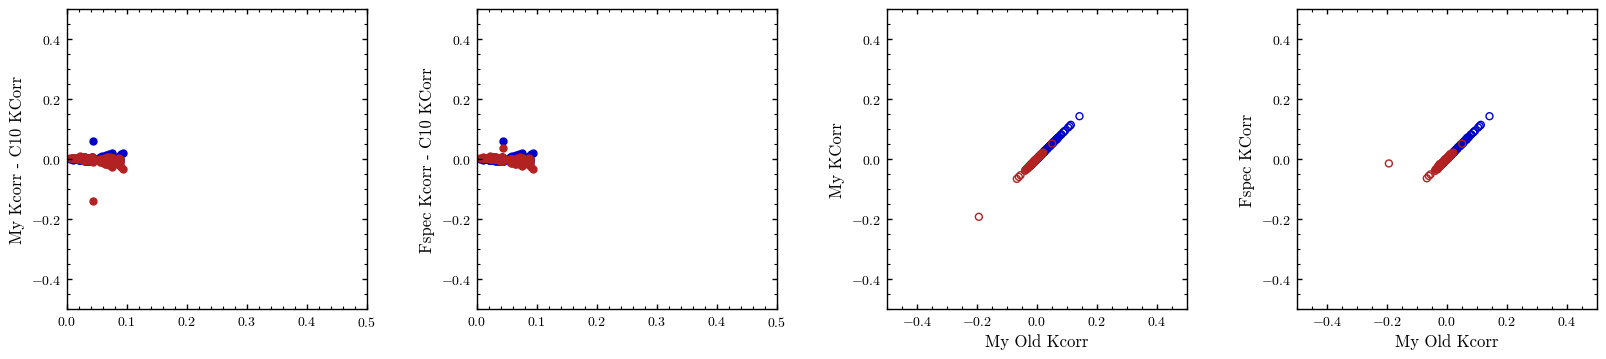

In [31]:
fig,ax = make_subplots(ncol=4,nrow=1,plot_size=3,return_fig=True)

ax[0].scatter(all_zreds, np.array(meas_kcorr_g) - np.array(c10_kcorr_g), color="mediumblue" )
ax[0].scatter(all_zreds, np.array(meas_kcorr_r) - np.array(c10_kcorr_r), color="firebrick" )
ax[0].set_ylabel("My Kcorr - C10 KCorr")


ax[1].scatter(all_zreds, np.array(fsf_kcorr_g) - np.array(c10_kcorr_g), color="mediumblue" )
ax[1].scatter(all_zreds, np.array(fsf_kcorr_r) - np.array(c10_kcorr_r), color="firebrick" )
ax[1].set_ylabel("Fspec Kcorr - C10 KCorr")

#####

ax[2].scatter(np.array(old_kcorr_g), np.array(meas_kcorr_g), edgecolor="mediumblue",facecolor="none" )
ax[2].scatter(np.array(old_kcorr_r), np.array(meas_kcorr_r), edgecolor="firebrick", facecolor="none" )
ax[2].set_xlabel("My Old Kcorr")
ax[2].set_ylabel("My KCorr")


ax[3].scatter(np.array(old_kcorr_g), np.array(fsf_kcorr_g), edgecolor="mediumblue",facecolor="none" )
ax[3].scatter(np.array(old_kcorr_r), np.array(fsf_kcorr_r), edgecolor="firebrick", facecolor="none" )
ax[3].set_xlabel("My Old Kcorr")
ax[3].set_ylabel("Fspec KCorr")

###

ax[0].set_ylim([-0.5,0.5])
ax[0].set_xlim([0,0.5])
ax[1].set_ylim([-0.5,0.5])
ax[1].set_xlim([0,0.5])

ax[2].set_ylim([-0.5,0.5])
ax[2].set_xlim([-0.5,0.5])

ax[3].set_ylim([-0.5,0.5])
ax[3].set_xlim([-0.5,0.5])

plt.show()


Validate the k corrections computed in the pipeline!

In [2]:
cat_2 = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")

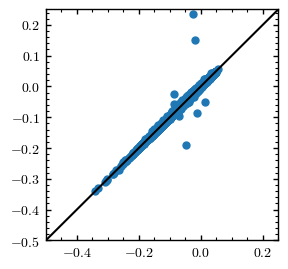

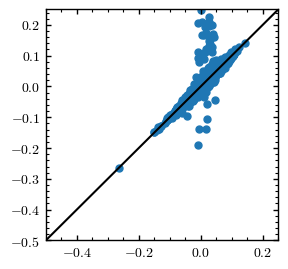

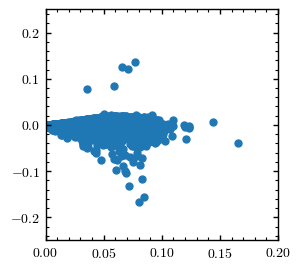

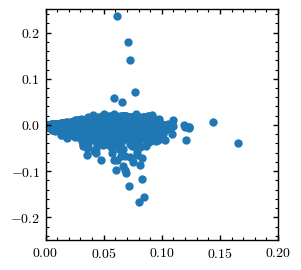

In [20]:
plt.figure(figsize = (3,3))
plt.scatter( cat_2["DELTA_MAG_G_KCORR"].data, cat_2["DELTA_MAG_G_KCORR_MODEL_EXT"].data)
plt.plot([-1,1],[-1,1],color="k")
plt.xlim([-0.5,0.25])
plt.ylim([-0.5,0.25])
plt.show()

plt.figure(figsize = (3,3))
plt.scatter( cat_2["DELTA_MAG_R_KCORR"].data, cat_2["DELTA_MAG_R_KCORR_MODEL_EXT"].data)
plt.plot([-1,1],[-1,1],color="k")
plt.xlim([-0.5,0.25])
plt.ylim([-0.5,0.25])
plt.show()


plt.figure(figsize = (3,3))

kcorr_fit = g_kcorr(cat_2["MAG_G_SDSS_MODEL_NOEMI"].data - cat_2["MAG_R_SDSS_MODEL_NOEMI"].data, cat_2["Z"].data) 

plt.scatter( cat_2["Z"].data, cat_2["DELTA_MAG_G_KCORR"].data + kcorr_fit)
plt.xlim([0,0.2])
plt.ylim([-0.25,0.25])
plt.show()

###

plt.figure(figsize = (3,3))
kcorr_fit = g_kcorr(cat_2["MAG_G_SDSS_MODEL_NOEMI"].data - cat_2["MAG_R_SDSS_MODEL_NOEMI"].data, cat_2["Z"].data) 
plt.scatter( cat_2["Z"].data, cat_2["DELTA_MAG_G_KCORR_MODEL_EXT"].data + kcorr_fit)
plt.xlim([0,0.2])
plt.ylim([-0.25,0.25])
plt.show()



In [21]:
##then we compare the k corrections computed above!!

In [34]:
# all_tgids, fsf_kcorr_g

In [36]:
matched_kcorr_g = []
matched_kcorr_r = []

for tidi in all_tgids:
    matched_kcorr_r.append( float(cat_2[cat_2["TARGETID"] ==  tidi]["DELTA_MAG_R_KCORR"]) )
    matched_kcorr_g.append( float(cat_2[cat_2["TARGETID"] ==  tidi]["DELTA_MAG_G_KCORR"]) )
    

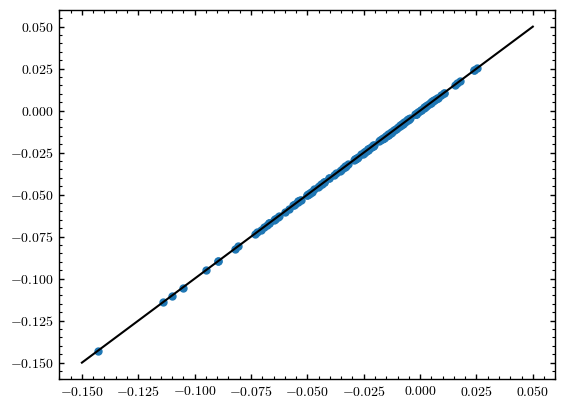

In [41]:
plt.scatter(matched_kcorr_g, -1*np.array(fsf_kcorr_g) )
plt.plot([-0.15,0.05], [-0.15,0.05],color="k")
plt.show()

##YAY! This is expected as the k corrections we compute are opposite of normal convention as we want to add them all!!